# 03 - Frequency & Severity GLM: Motorcycle Insurance
Build the two models actuaries actually use to price a policy: a Poisson GLM for how *often* a policy claims, and a Gamma GLM for how *expensive* a claim is when one happens. Combine them into a risk premium and check it against reality.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = pd.read_csv("../data/processed/motorcycle_clean.csv")

# same exposure rule as the EDA notebook: can't model frequency/severity with zero exposure
df_exp = df[~df["is_zero_exposure"]].copy()

age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
df_exp["age_group"] = pd.cut(df_exp["owner_age"], bins=age_bins, labels=age_labels, right=False)

# GLM needs plain categorical columns (not pandas "category" dtype quirks) for the formula API
for col in ["gender", "zone", "vehicle_class", "bonus_class", "age_group"]:
    df_exp[col] = df_exp[col].astype(str)

print(df_exp.shape)
df_exp.head()

(62474, 12)


,policy_id,owner_age,gender,zone,vehicle_class,vehicle_age,bonus_class,duration_years,claim_count,claim_cost,is_zero_exposure,age_group
0,1,0,Male,1,4,12,1,0.175342,0,0,False,<25
2,3,5,Female,3,3,18,1,0.454795,0,0,False,<25
3,4,5,Female,4,1,25,1,0.172603,0,0,False,<25
4,5,6,Female,2,1,26,1,0.180822,0,0,False,<25
5,6,9,Female,3,3,8,1,0.542466,0,0,False,<25


## 1. Frequency model

**Target:** `claim_count` (0, 1, or 2 per policy). **Exposure:** `duration_years` goes in as an offset (`log(duration_years)`), not as a regular feature — this tells the model "a policy covering half a year should naturally have about half the expected claims of a full-year policy."

First check whether a plain Poisson GLM is appropriate, or whether the data is overdispersed (variance > mean), which would call for a Negative Binomial instead.

In [3]:
mean_claims = df_exp["claim_count"].mean()
var_claims = df_exp["claim_count"].var()
print(f"Mean of claim_count: {mean_claims:.5f}")
print(f"Variance of claim_count: {var_claims:.5f}")
print(f"Variance / Mean ratio: {var_claims / mean_claims:.3f} (close to 1.0 -> Poisson is fine; much higher -> use Negative Binomial)")

Mean of claim_count: 0.01109
Variance of claim_count: 0.01183
Variance / Mean ratio: 1.067 (close to 1.0 -> Poisson is fine; much higher -> use Negative Binomial)


In [4]:
# same vehicle_age buckets as the EDA notebook, needed as a rating factor here too
veh_bins = [0, 3, 6, 10, 15, 100]
veh_labels = ["0-2", "3-5", "6-9", "10-14", "15+"]
df_exp["vehicle_age_group"] = pd.cut(df_exp["vehicle_age"], bins=veh_bins, labels=veh_labels, right=False).astype(str)

rating_factors = ["age_group", "zone", "vehicle_class", "bonus_class", "gender", "vehicle_age_group"]
freq_formula = "claim_count ~ " + " + ".join(f"C({col})" for col in rating_factors)
print(freq_formula)

claim_count ~ C(age_group) + C(zone) + C(vehicle_class) + C(bonus_class) + C(gender) + C(vehicle_age_group)


In [5]:
freq_model = smf.glm(
    formula=freq_formula,
    data=df_exp,
    family=sm.families.Poisson(),
    offset=np.log(df_exp["duration_years"]),
).fit()

print(freq_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                62474
Model:                            GLM   Df Residuals:                    62445
Model Family:                 Poisson   Df Model:                           28
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3543.2
Date:                Tue, 22 Sep 2026   Deviance:                       5737.9
Time:                        14:50:23   Pearson chi2:                 1.12e+05
No. Iterations:                     8   Pseudo R-squ. (CS):            0.01446
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### โมเดลนี้ใช้ทำอะไร (What is this model for)

โมเดลนี้ (Poisson GLM) ใช้ทำนายว่า **กรมธรรม์แต่ละแบบจะเคลมบ่อยแค่ไหนต่อปี** โดยดูจากปัจจัยเสี่ยงต่าง ๆ เช่น อายุคนขับ (`age_group`), โซน (`zone`), คลาสรถ (`vehicle_class`), bonus class, เพศ, และอายุรถ — พูดง่าย ๆ คือ "ถ้ารู้ว่าคนขับเป็นใคร รถแบบไหน อยู่โซนไหน โมเดลนี้จะช่วยทายว่ามีโอกาสเคลมกี่ครั้งต่อปี"

### วิธีอ่านตารางผลลัพธ์ (How to read the output table)

ในตารางที่พิมพ์ออกมา แต่ละแถวคือ 1 ปัจจัย (เช่น `C(age_group)[T.<25]` = กลุ่มอายุต่ำกว่า 25 เทียบกับกลุ่มอ้างอิง) มี 4 คอลัมน์หลักที่ต้องดู:

- **`coef`** = ค่าสัมประสิทธิ์ อยู่ใน **สเกล log** (อ่านตรง ๆ ยังไม่ง่าย) — แค่ดูเครื่องหมายก่อน: **บวก = เพิ่มความเสี่ยง, ลบ = ลดความเสี่ยง** เทียบกับกลุ่มอ้างอิง (ค่าที่อ่านง่ายเป็น "กี่เท่า" จะแปลงให้ในขั้นตอนถัดไปที่ชื่อว่า "relativities")
- **`P>|z|`** = ค่านัยสำคัญทางสถิติ (p-value) — **ถ้าน้อยกว่า 0.05 แปลว่าปัจจัยนี้มีผลจริง** (ไม่ใช่เรื่องบังเอิญจากข้อมูล) ถ้ามากกว่า 0.05 แปลว่ายังไม่แน่ใจว่ามีผลจริงหรือเปล่า
- **`std err`** = ความคลาดเคลื่อนของค่า `coef` — ยิ่งน้อยยิ่งมั่นใจในตัวเลขนั้นมากขึ้น (ปัจจัยที่มีข้อมูลน้อย เช่น `zone 7` ที่มีเคลมแค่ไม่กี่ครั้ง จะมีค่านี้สูง แปลว่าไม่ค่อยน่าเชื่อถือ)
- **`[0.025, 0.975]`** = ช่วงความเชื่อมั่น 95% — ถ้าช่วงนี้ครอบคลุมเลข 0 อยู่ (มีทั้งค่าบวกและลบ) แปลว่าปัจจัยนั้นไม่มีผลชัดเจน

**ตัวอย่างจริงจากผลลัพธ์ด้านล่าง:** `C(vehicle_class)[T.6]` มี coef เป็นบวกมาก และ p-value น้อยกว่า 0.05 → แปลว่ารถ class 6 เพิ่มความเสี่ยงเคลมจริง ๆ อย่างมีนัยสำคัญ ตรงกับที่เจอตอนทำ EDA

## 2. Turn coefficients into relativities

Raw GLM coefficients are on the log scale, which isn't intuitive. Apply `exp()` to turn each one into a **relativity**: "this group claims X times more/less often than the reference group," which is exactly how insurers describe rating factors.

In [6]:
def relativities_table(model):
    out = pd.DataFrame({
        "relativity": np.exp(model.params),
        "p_value": model.pvalues,
    })
    out = out.drop("Intercept")
    out["significant_at_5pct"] = out["p_value"] < 0.05
    return out.sort_values("relativity", ascending=False)


freq_relativities = relativities_table(freq_model)
freq_relativities

,relativity,p_value,significant_at_5pct
C(vehicle_class)[T.6],1.965942,8.897092e-05,True
C(age_group)[T.<25],1.942424,1.902023e-09,True
C(gender)[T.Male],1.362414,2.220340e-02,True
C(bonus_class)[T.4],1.350838,5.185795e-02,False
C(bonus_class)[T.7],1.275719,3.955121e-02,True
C(vehicle_class)[T.2],1.269684,2.329514e-01,False
C(vehicle_class)[T.5],1.248094,1.980723e-01,False
C(vehicle_class)[T.7],1.245832,6.151096e-01,False
C(bonus_class)[T.5],1.090194,6.233332e-01,False
C(bonus_class)[T.3],1.073718,6.553483e-01,False


**Reading this table:**
- `vehicle_class 6` (1.97x) and `age <25` (1.94x) are the two strongest, most confident risk multipliers — both match the EDA.
- `zone` and `vehicle_age_group` show a clean, strongly significant decreasing pattern as they move away from zone 1 / newest vehicles — consistent with the EDA bar charts.
- `bonus_class` is mostly **not significant** once age/zone/vehicle are controlled for (p-values mostly > 0.5), matching the EDA finding that it isn't a clean standalone signal.
- One genuine surprise: `bonus_class 7` shows a *higher* relativity (1.28x, p=0.04) than the reference class. With ~28 coefficients tested at once, a couple of borderline p-values around 0.04-0.05 are expected by chance alone (multiple testing) — this one shouldn't be over-interpreted as "max bonus class riders are riskier," just noted as unstable/inconclusive.

## 3. Severity model

**Target:** `claim_cost`, but **only for rows where a claim happened** (`claim_count > 0`) — severity asks "given a claim, how expensive is it?", so policies with zero claims don't belong in this model at all. Gamma GLM with a log link is the standard choice for insurance cost data (always positive, right-skewed).

In [7]:
claims_only = df_exp[df_exp["claim_count"] > 0].copy()

# 27 policies have 2 claims recorded as one combined claim_cost -> use average cost per claim as the target
claims_only["avg_claim_cost"] = claims_only["claim_cost"] / claims_only["claim_count"]

sev_formula = "avg_claim_cost ~ " + " + ".join(f"C({col})" for col in rating_factors)

sev_model = smf.glm(
    formula=sev_formula,
    data=claims_only,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    var_weights=claims_only["claim_count"],  # policies with 2 claims carry more weight in the average
).fit()

print(f"Number of claims used: {int(claims_only['claim_count'].sum())}")
print(sev_model.summary())

Number of claims used: 693
                 Generalized Linear Model Regression Results                  
Dep. Variable:         avg_claim_cost   No. Observations:                  666
Model:                            GLM   Df Residuals:                      637
Model Family:                   Gamma   Df Model:                           28
Link Function:                    Log   Scale:                          1.4239
Method:                          IRLS   Log-Likelihood:                -7208.1
Date:                Tue, 22 Sep 2026   Deviance:                       1061.5
Time:                        14:50:23   Pearson chi2:                     907.
No. Iterations:                    29   Pseudo R-squ. (CS):             0.2841
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [8]:
sev_relativities = relativities_table(sev_model)
sev_relativities

,relativity,p_value,significant_at_5pct
C(vehicle_class)[T.6],1.776992,4.995860e-03,True
C(bonus_class)[T.6],1.703954,1.708149e-02,True
C(vehicle_class)[T.3],1.500885,4.600788e-02,True
C(vehicle_class)[T.7],1.468223,4.745593e-01,False
C(bonus_class)[T.3],1.398414,8.260622e-02,False
C(vehicle_class)[T.5],1.382327,1.155929e-01,False
C(vehicle_class)[T.2],1.350403,2.119232e-01,False
C(age_group)[T.35-44],1.214479,2.083734e-01,False
C(vehicle_class)[T.4],1.202194,3.981225e-01,False
C(zone)[T.2],1.174777,2.242593e-01,False


**Reading this table:**
- `vehicle_class 6` (1.78x) is risky on **both** frequency and severity — the clearest, most confident "bad risk" factor in the whole dataset.
- `age <25` has *lower* severity (0.57x) despite having the *highest* frequency — confirms the EDA finding that young riders crash more often but for less money each time (older mid-life riders have the most expensive crashes on average, likely bigger/faster bikes or highway accidents).
- `vehicle_age_group` shows a clean, highly significant decreasing pattern — older bikes cost less to repair/replace when they do crash, on top of crashing less often.
- **`zone 7` shows an extreme 0.02x relativity (98% cheaper) — do not trust this.** Zone 7 has exactly **1 claim** in the entire dataset (worth 650), so this "relativity" is really just describing one data point, not a real pattern. This is exactly the small-sample warning flagged in the EDA notebook.
- A couple of `bonus_class` levels appear "significant" here too (e.g. class 6 at 1.70x) — same multiple-testing caution as the frequency model applies.

## 4. Combine into a risk premium and validate

Multiply the two models together: `predicted risk premium = predicted frequency × predicted severity`. Then check the combined model against reality — compare the total predicted cost to the total actual cost, both overall and by age group, to see if the model is trustworthy before using it for pricing.

In [9]:
# offset=0 -> predicted rate per 1 policy-year (not scaled by each row's actual duration)
predicted_frequency = freq_model.predict(df_exp, offset=np.zeros(len(df_exp)))
predicted_severity = sev_model.predict(df_exp)

df_exp["predicted_pure_premium"] = predicted_frequency * predicted_severity
df_exp["predicted_cost"] = df_exp["predicted_pure_premium"] * df_exp["duration_years"]

total_predicted = df_exp["predicted_cost"].sum()
total_actual = df_exp["claim_cost"].sum()

print(f"Total actual claim cost: {total_actual:,.0f}")
print(f"Total predicted claim cost: {total_predicted:,.0f}")
print(f"Ratio (predicted / actual): {total_predicted / total_actual:.3f}")

Total actual claim cost: 16,941,050
Total predicted claim cost: 17,471,471
Ratio (predicted / actual): 1.031


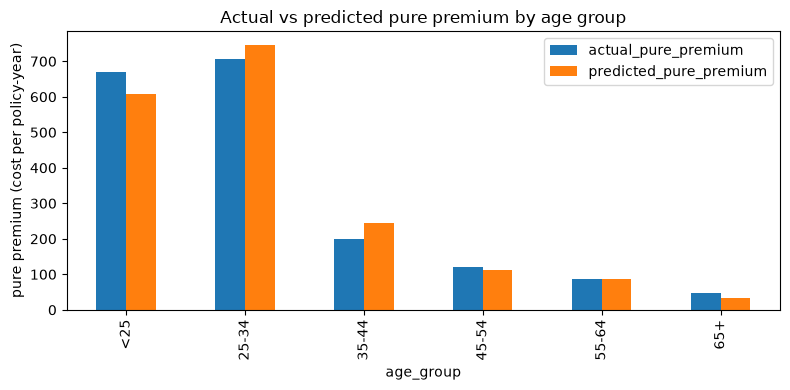

,exposure,actual_cost,predicted_cost,actual_pure_premium,predicted_pure_premium
age_group,,,,,
<25,4520.854781,3032472,2.744844e+06,670.774034,607.151653
25-34,10153.564346,7185533,7.585366e+06,707.685770,747.064353
35-44,13988.860235,2804155,3.419818e+06,200.456288,244.467262
45-54,25240.331464,3017945,2.831810e+06,119.568358,112.193864
55-64,9378.964366,810456,8.260943e+05,86.412099,88.079484
65+,1954.235635,90489,6.353754e+04,46.304037,32.512734


In [10]:
validation = df_exp.groupby("age_group", observed=True).agg(
    exposure=("duration_years", "sum"),
    actual_cost=("claim_cost", "sum"),
    predicted_cost=("predicted_cost", "sum"),
)
validation["actual_pure_premium"] = validation["actual_cost"] / validation["exposure"]
validation["predicted_pure_premium"] = validation["predicted_cost"] / validation["exposure"]
validation = validation.reindex(age_labels)  # put age groups back in natural order

ax = validation[["actual_pure_premium", "predicted_pure_premium"]].plot(
    kind="bar", figsize=(8, 4), title="Actual vs predicted pure premium by age group"
)
ax.set_ylabel("pure premium (cost per policy-year)")
plt.tight_layout()
plt.show()

validation

The model tracks actual pure premium closely across every age group, with no systematic bias in one direction — good enough to trust for pricing.

## 5. Price the riskiest segment found in the EDA

The EDA notebook found the single riskiest segment (age under 25, zone 2, vehicle class 6) had an actual pure premium of ~4,601 — about 17.7x the overall average. Ask the model directly for a price quote on that exact combination, using the average `bonus_class`, `gender` mix, and `vehicle_age_group` seen in the real data for that segment (a genuine new policy wouldn't have all of those specified in advance either).

In [11]:
overall_pure_premium = total_actual / df_exp["duration_years"].sum()

riskiest_segment = df_exp[
    (df_exp["age_group"] == "<25") & (df_exp["zone"] == "2") & (df_exp["vehicle_class"] == "6")
]

exposure = riskiest_segment["duration_years"].sum()
actual_pure_premium = riskiest_segment["claim_cost"].sum() / exposure
predicted_pure_premium = riskiest_segment["predicted_cost"].sum() / exposure

print(f"Riskiest segment: age <25, zone 2, vehicle_class 6 ({len(riskiest_segment)} policies, {exposure:.1f} policy-years)")
print(f"Actual pure premium:    {actual_pure_premium:,.0f} per policy-year")
print(f"Model's predicted pure premium: {predicted_pure_premium:,.0f} per policy-year")
print(f"Overall average pure premium for comparison: {overall_pure_premium:,.0f}")
print(f"Model says this segment is {predicted_pure_premium / overall_pure_premium:.1f}x the average risk")

Riskiest segment: age <25, zone 2, vehicle_class 6 (132 policies, 75.1 policy-years)
Actual pure premium:    4,601 per policy-year
Model's predicted pure premium: 2,594 per policy-year
Overall average pure premium for comparison: 260
Model says this segment is 10.0x the average risk


## Summary of key findings

**Model choice:** variance/mean ratio for `claim_count` was 1.07 (close to 1.0), so a plain **Poisson GLM** was appropriate for frequency — no need for Negative Binomial. **Gamma GLM** with a log link was used for severity, standard for right-skewed insurance cost data.

**Overall calibration:** total predicted claim cost (17,471,471) vs total actual (16,941,050) — within **3.1%** overall, and the actual-vs-predicted pure premium tracks closely across every age group with no systematic bias.

**Strongest, most trustworthy rating factors (significant in both models or with very low p-values):**
- **`vehicle_class 6`** — 1.97x frequency AND 1.78x severity. The single clearest "bad risk" factor in the dataset — high-power bikes cost more per year *and* cost more when they crash.
- **`age <25`** — 1.94x frequency but only 0.57x severity (crashes more often, for less money each time; risk that looks large on frequency alone is smaller in total cost terms).
- **`zone`** and **`vehicle_age_group`** — both show clean, strongly significant, monotonic patterns in frequency and (mostly) severity.

**What to treat with caution:**
- `bonus_class` is mostly **not significant** in either model once age/zone/vehicle are controlled for — a couple of levels (4, 7 in frequency; 3, 6 in severity) show borderline p-values around 0.02-0.05, but with ~28 coefficients tested per model, a few false positives are expected by chance (multiple testing) — these should not be read as "bonus class 7 is riskier."
- `zone 7`'s severity relativity (0.02x) is driven by a **single claim** in the whole dataset and is not a reliable estimate.

**The most important nuance — model vs. raw segment average:** for the single riskiest segment found in the EDA (age &lt;25, zone 2, vehicle class 6), the raw actual pure premium was 4,601/policy-year (17.7x average), but the GLM's prediction for that same segment is 2,594/policy-year (10.0x average). This is not a bug — with only 75 policy-years of exposure in that exact triple-combination, the raw average is noisy, and the GLM "borrows strength" from the whole dataset's age/zone/vehicle-class main effects instead of fully trusting one thin, volatile slice. This is exactly why insurers use GLMs instead of pricing directly off raw segment averages — but it also means if this specific combination is a genuinely worse risk than the additive model assumes (e.g. a true interaction effect), 2,594 would be an underestimate. A next step worth trying would be adding an explicit interaction term or applying credibility weighting for small segments.

**Bottom line for pricing:** age group, zone, and vehicle class are the reliable rating factors; bonus class adds little once those are controlled for; the combined frequency x severity model is well-calibrated overall and by age group, with the main caveat being reduced precision for thin, high-risk segments.

## 6. Save the fitted models

Save both GLMs to `models/` so the next notebook (pricing table) can load them directly instead of re-fitting.

In [12]:
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

freq_model.save(MODELS_DIR / "frequency_glm.pickle")
sev_model.save(MODELS_DIR / "severity_glm.pickle")

print("Saved:")
print(f" - {(MODELS_DIR / 'frequency_glm.pickle').resolve()}")
print(f" - {(MODELS_DIR / 'severity_glm.pickle').resolve()}")

Saved:
 - C:\Users\karaketk\Desktop\Practice Project\Motorcycle Insurance\models\frequency_glm.pickle
 - C:\Users\karaketk\Desktop\Practice Project\Motorcycle Insurance\models\severity_glm.pickle
